# Road Segmentation

The model is trained for the task of segmentation on satellite imagery

(147, 154, 3)


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


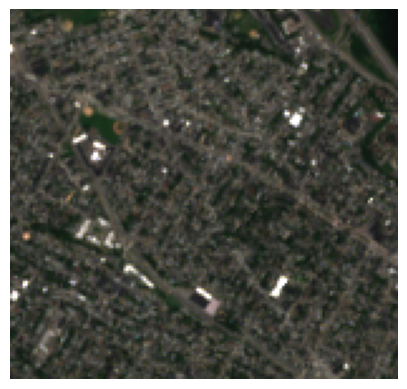

In [1]:

from PIL import Image
import matplotlib.pyplot as plt
import rasterio as rio
import numpy as np
from skimage.io import imsave
import random
from glob import glob

img_paths = glob('samples/s2_roads/*.tiff')
img_path = random.choice(img_paths)

def tif2rgb(tif_path):
	x = rio.open(tif_path).read((4,3,2)) # read RGB bands
	# x = rio.open(tif_path).read((1,2,3)) # read RGB bands
	x = np.clip(x / 4000, 0, 1) # normalize to 0-1 with increased brightness
	x = (x * 255).astype(np.uint8) # convert to uint8
	x = x.transpose(1,2,0) # convert to HWC
	# x = resize(x, (256,256))
	# x = (x * 255).astype(np.uint8) # convert to uint8
	# crop
	# x = x[-512:,-512:,:]
	print(x.shape)
	new_path = tif_path.replace('.tiff', '.png')
	imsave(new_path, x)
	return new_path

img_path = tif2rgb(img_path)

img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()

In [2]:
import requests

url = f'http://localhost:8000/'
# url  = f'https://eotdl.dev.gda.adamplatform.eu/RoadSegmentationQ2'

res = requests.get(url)

res.json()


{'message': 'Hello from the ml-inference API!',
 'version': '2025.02.26',
 'auth_required': False}

In [3]:
from IPython.display import JSON
import json

url = f'http://localhost:8000/MassachusettsRoadsS2Model'
# url  = f'https://eotdl.dev.gda.adamplatform.eu/RoadSegmentationQ2'

headers = {	
    "X-API-Key": "123"
}

res = requests.get(url, headers=headers)

if res.status_code == 200:
   print(res.json())

[{'type': 'Feature', 'stac_version': '1.0.0', 'stac_extensions': [], 'id': 'model.onnx', 'bbox': [0.0, 0.0, 0.0, 0.0], 'geometry': {'type': 'Polygon', 'coordinates': []}, 'assets': {'asset': {'checksum': 'f313a4bf02afd1a6b558299c3560e9380093d6a0', 'href': 'https://api.eotdl.com/datasets/683eece500cf9ffafe807823/stage/model.onnx', 'size': 97749515, 'timestamp': '2025-09-23T11:42:09.903136'}}, 'links': [], 'properties': {'repository': 'eotdl', 'mlm:name': 'model.onnx', 'mlm:framework': 'ONNX', 'mlm:architecture': 'U-Net', 'mlm:tasks': ['segmentation'], 'mlm:input': {'bands': ['red', 'green', 'blue'], 'input': {'data_type': 'float32', 'description': 'Model trained with Sentinel2 RGB images, can work with any dimensions as long as they are divisible by 16', 'dim_order': ['batch', 'channel', 'height', 'width'], 'shape': [-1, 3, -1, -1]}, 'name': 'RGB statellite image (Sentinel 2)'}, 'mlm:output': {'name': 'road binary mask', 'result': {'data_type': 'uint8', 'description': 'Binary mask of th

In [4]:
res = requests.post(url,  files={'image': (open(img_path, 'rb'))}, headers=headers)

if res.status_code != 200:
   print(res.json())

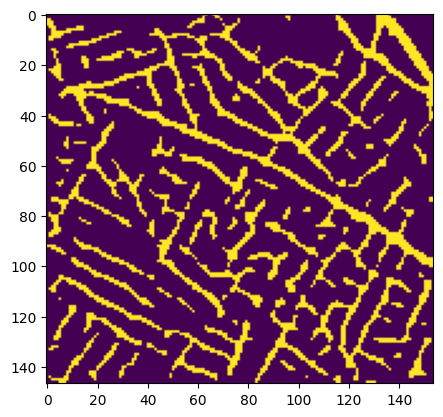

In [5]:
import numpy as np
import io 
from PIL import Image
import numpy as np 

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Assuming `response` is an image
res = requests.post(url,  files={'image': (open(img_path, 'rb'))}, headers=headers)

image_bytes = io.BytesIO(res.content)
img = Image.open(image_bytes)

probas = np.array(img) 
# probas = sigmoid(logits)
mask = probas > 0.5 # use different thresholds for sensitivity analysis
# mask = img

# plt.imshow(array)
plt.imshow(mask)

# mask.shape, mask.dtype, mask.min(), mask.max()

In [38]:
probas.min(), probas.max()

(np.float32(2.0485206e-06), np.float32(0.88894594))